<a href="https://colab.research.google.com/github/revxx26/telco-customer-churn-analysis/blob/main/ANALISA_CHURN_TELEKOMUNIKASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis & Prediksi Customer Churn Telco Company
menganalisis pola churn pelanggan dan membangun model prediksi menggunakan Logistic Regression.

# Data Loading

In [ ]:
import os
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from google.colab import files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving telco_customer.xls to telco_customer.xls


In [ ]:
os.makedirs("data", exist_ok=True)
conn = sql.connect("data/churn.db")

In [ ]:
df = pd.read_csv("telco_customer.xls")
df.to_sql("raw_customers", conn, if_exists="replace", index=False)

7043

# Data Cleaning

In [ ]:
cleaned_df = pd.read_sql("""
SELECT
    customerID,
    gender,
    SeniorCitizen,
    Partner,
    Dependents,
    tenure,
    Contract,
    InternetService,
    PaymentMethod,
    CAST(MonthlyCharges AS FLOAT) AS monthly_charges,
    CASE WHEN TotalCharges = ' ' THEN NULL ELSE CAST(TotalCharges AS FLOAT) END AS total_charges,
    CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END AS churn_flag
FROM raw_customers;
""", conn)

cleaned_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,InternetService,PaymentMethod,monthly_charges,total_charges,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,Month-to-month,DSL,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,One year,DSL,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Month-to-month,DSL,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,One year,DSL,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Month-to-month,Fiber optic,Electronic check,70.70,151.65,1


In [ ]:
cleaned_df.info()
print("Jumlah Missing per Kolom:")
print(cleaned_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   gender           7043 non-null   object 
 2   SeniorCitizen    7043 non-null   int64  
 3   Partner          7043 non-null   object 
 4   Dependents       7043 non-null   object 
 5   tenure           7043 non-null   int64  
 6   Contract         7043 non-null   object 
 7   InternetService  7043 non-null   object 
 8   PaymentMethod    7043 non-null   object 
 9   monthly_charges  7043 non-null   float64
 10  total_charges    7032 non-null   float64
 11  churn_flag       7043 non-null   int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 660.4+ KB
Jumlah Missing per Kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
Contract            0
Inter

In [ ]:
cleaned_df=cleaned_df.dropna(subset=['total_charges'])
print("Jumlah baris setelah drop NULL:", len(cleaned_df))

Jumlah baris setelah drop NULL: 7032


In [ ]:
cleaned_df.to_sql("analytic_table", conn, if_exists="replace", index=False)

7032

# Exploratory Data Analyst


In [25]:
churn_rate = cleaned_df['churn_flag'].mean()*100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.58%


Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: churn_flag, dtype: float64


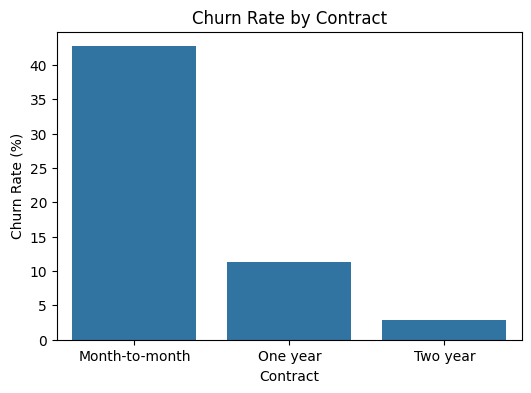

In [ ]:
churn_by_contract = cleaned_df.groupby('Contract')['churn_flag'].mean() * 100
print(churn_by_contract)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values)
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract")
plt.show()


/tmp/ipykernel_935/3418366628.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = cleaned_df.groupby('tenure_group')['churn_flag'].mean() * 100


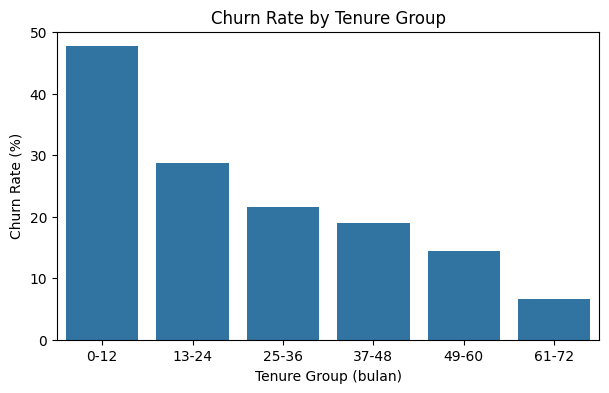

In [ ]:
cleaned_df['tenure_group'] = pd.cut(cleaned_df['tenure'], bins=[0,12,24,36,48,60,72], labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

churn_by_tenure = cleaned_df.groupby('tenure_group', observed=True)['churn_flag'].mean() * 100

plt.figure(figsize=(7,4))
sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values)
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group (bulan)")
plt.title("Churn Rate by Tenure Group")
plt.show()

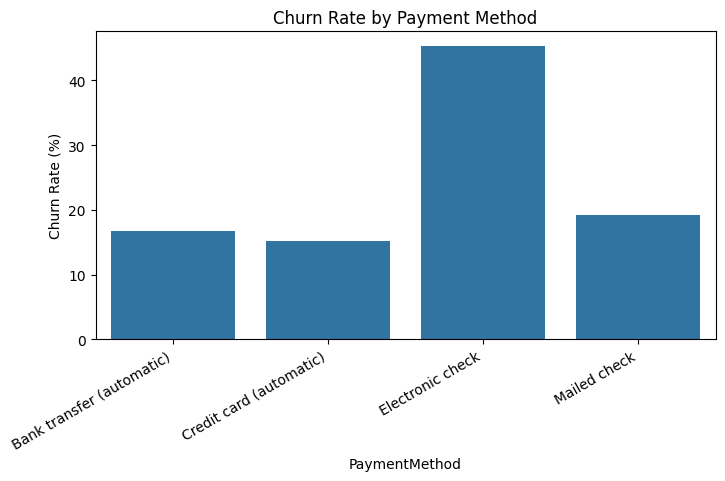

In [ ]:
churn_by_payment = cleaned_df.groupby('PaymentMethod')['churn_flag'].mean() * 100
plt.figure(figsize=(8,4))
sns.barplot(x=churn_by_payment.index, y=churn_by_payment.values)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")
plt.show()

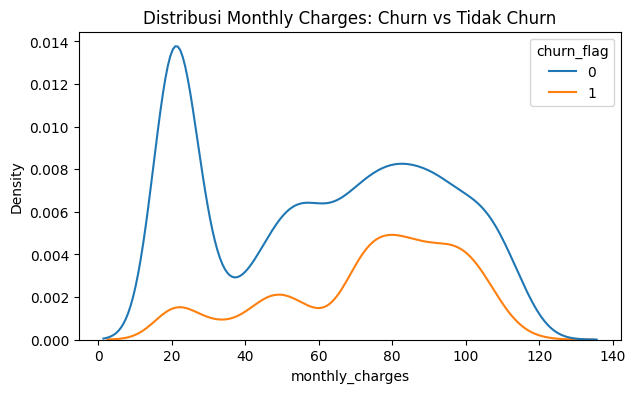

In [ ]:
plt.figure(figsize=(7,4))
sns.kdeplot(data=cleaned_df, x='monthly_charges', hue='churn_flag')
plt.title("Distribusi Monthly Charges: Churn vs Tidak Churn")
plt.show()

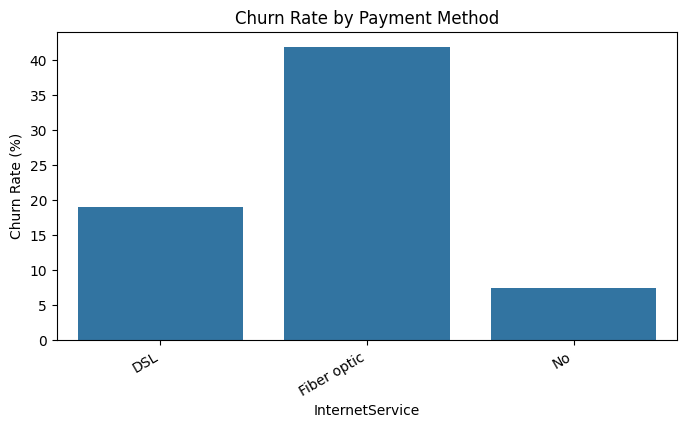

In [ ]:
churn_by_internet = cleaned_df.groupby('InternetService')['churn_flag'].mean() * 100
plt.figure(figsize=(8,4))
sns.barplot(x=churn_by_internet.index, y=churn_by_internet.values)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")
plt.show()

INSIGHT


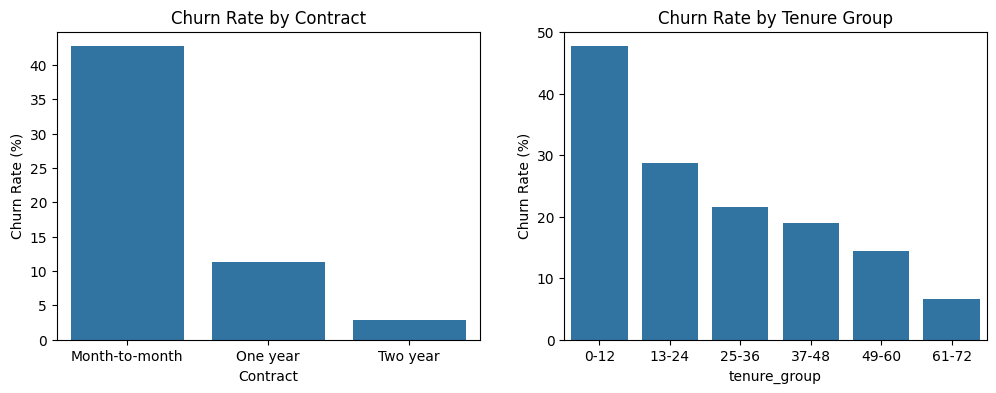

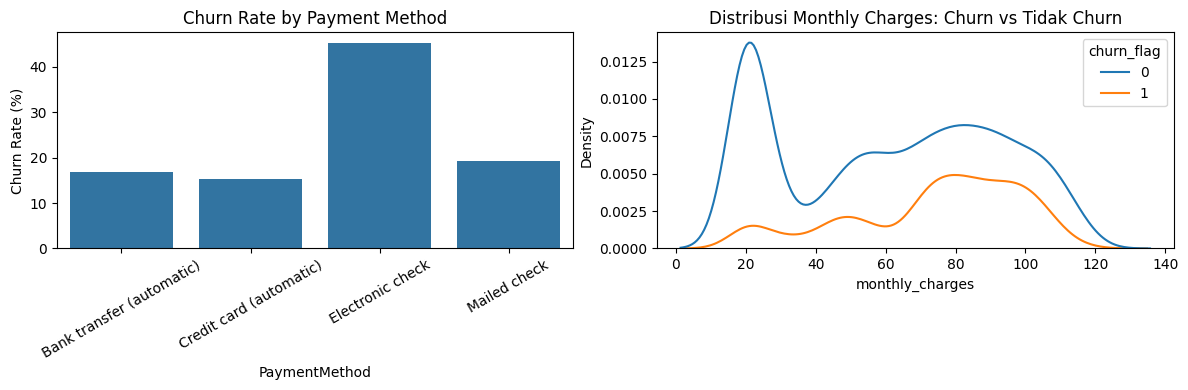

In [ ]:
print("INSIGHT")

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(data=churn_by_contract, ax=axes[0])
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_title("Churn Rate by Contract")

sns.barplot(data=churn_by_tenure, ax=axes[1])
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_title("Churn Rate by Tenure Group")


fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(data=churn_by_payment, ax=axes[0])
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_title("Churn Rate by Payment Method")
axes[0].tick_params(axis='x', rotation=30)

sns.kdeplot(data=cleaned_df, x='monthly_charges', hue='churn_flag', ax=axes[1])
axes[1].set_title("Distribusi Monthly Charges: Churn vs Tidak Churn")

plt.tight_layout()
plt.show()

Setelah melakukan analisa pada 4 X terhadap churn, dapat di deskripsikan

By Contract = pelanggan dengan masa langganan perbulan lebih banyak yang chrun di banding dengan pelanggan yang berlangganan langsung setahun dua tahun. Karena kebanyakan orang memilih berlangganan bulanan, ketimbang tahunan. Jadi wajar aja kalo yang bulanan lebi banyak churn karena jumlah pelanggan nya lebi banyak yang bulanan

By tunure = masa berlangganan 0 - 12 lebih banyak pelanggan yang churn, di bandingkan dengan pelanggan yang masa berlangganan nya lebi dari 12 bulan

By PaymentMethod = banyak pelanggan menggunakan metode electronic check (pembayaran nya tidak otomatis terpotong dari saldo tiap bulan) yang churn

Hasil kurva dari Distribusi Monthly Charges menunjukan pelanggan dengan tagihan rendah mendominasi tidak churn, namun kurva dengan tagihan relatif tinggi tidak menunjukan perbedaan yang tegas.


# Statistical Testing



In [26]:
categorical_vars = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'tenure_group', 'InternetService']

result = []
for col in categorical_vars:
    contingency_table = pd.crosstab(cleaned_df[col], cleaned_df['churn_flag'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    result.append({
        'variable': col,
        'chi2' : round(chi2, 2),
        'p-value' : round (p, 6),
        'significant': 'Yes' if p < 0.05 else 'No'
    })

chi_square_result = pd.DataFrame(result).sort_values('chi2', ascending=False)
chi_square_result

,variable,chi2,p-value,significant
4,Contract,1179.55,0.000000,Yes
6,tenure_group,881.76,0.000000,Yes
7,InternetService,728.70,0.000000,Yes
5,PaymentMethod,645.43,0.000000,Yes
3,Dependents,186.32,0.000000,Yes
1,SeniorCitizen,158.44,0.000000,Yes
2,Partner,157.50,0.000000,Yes
0,gender,0.48,0.490488,No


# Modeling


In [ ]:
model_df = df.merge(cleaned_df[['customerID','monthly_charges','total_charges','churn_flag']],
                  on='customerID', how='inner')
model_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,monthly_charges,total_charges,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.5,No,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,70.70,151.65,1


In [ ]:
categorical_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines',
                     'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
                     'TechSupport','StreamingTV','StreamingMovies','Contract',
                     'PaperlessBilling','PaymentMethod']

model_df_encoded = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

In [ ]:
x = model_df_encoded.drop(columns=['customerID','Churn','churn_flag','MonthlyCharges','TotalCharges'])
y = model_df_encoded['churn_flag']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=69, stratify=y
)

In [ ]:
scaler = StandardScaler ()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407

AUC Score: 0.8472803888782476


In [ ]:
coef_df = pd.DataFrame({
    'feature': x.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Top 10 fitur yang MENAIKKAN risiko churn:")
print(coef_df.head(10))

print("\nTop 10 fitur yang MENURUNKAN risiko churn:")
print(coef_df.tail(10))

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df_sorted = coef_df.sort_values('abs_coefficient', ascending=False)
coef_df_sorted.to_csv('feature_importance.csv', index=False)

files.download('feature_importance.csv')

Top 10 fitur yang MENAIKKAN risiko churn:
                           feature  coefficient
3                    total_charges     0.566320
10     InternetService_Fiber optic     0.452205
26            PaperlessBilling_Yes     0.205214
28  PaymentMethod_Electronic check     0.168757
21                 StreamingTV_Yes     0.163048
23             StreamingMovies_Yes     0.146743
9                MultipleLines_Yes     0.120336
0                    SeniorCitizen     0.070595
8   MultipleLines_No phone service     0.037323
4                      gender_Male     0.017627

Top 10 fitur yang MENURUNKAN risiko churn:
                                 feature  coefficient
18       TechSupport_No internet service    -0.055360
16  DeviceProtection_No internet service    -0.055360
22   StreamingMovies_No internet service    -0.055360
6                         Dependents_Yes    -0.076159
13                    OnlineSecurity_Yes    -0.125199
19                       TechSupport_Yes    -0.161384
2       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results_df = model_df_encoded[['customerID']].copy()
results_df['churn_probability'] = model.predict_proba(scaler.transform(x))[:, 1]
results_df = results_df.sort_values('churn_probability', ascending=False)

results_df.to_sql("churn_predictions", conn, if_exists="replace", index=False)
results_df.to_csv("churn_predictions.csv", index=False)
results_df.head(20)

,customerID,churn_probability
1971,9497-QCMMS,0.941053
4792,9300-AGZNL,0.940843
3743,4424-TKOPW,0.939471
6359,2720-WGKHP,0.939183
3154,5150-ITWWB,0.938019
1405,7024-OHCCK,0.937053
3374,5178-LMXOP,0.936970
994,1374-DMZUI,0.934456
5980,5567-WSELE,0.933810
301,8098-LLAZX,0.933404


# Export

In [ ]:
cleaned_df['monthly_charges'] = cleaned_df['monthly_charges'].round(2)
cleaned_df['total_charges'] = cleaned_df['total_charges'].round(2)
results_df['churn_probability'] = results_df['churn_probability'].round(4)

cleaned_df.to_csv("analytic_table.csv", index=False)
results_df.to_csv("churn_predictions.csv", index=False)

files.download("analytic_table.csv")
files.download("churn_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>